# Large-System Pauli-Propagation Correlator

This notebook is a large-system version of `eigenvectors.ipynb`. It intentionally removes the dense exact eigensolver, the eigenvector heatmap, and all exact-reference curves so that the workflow can be run at larger `N`.

The plotted curves are Pauli-propagation approximations only. Use the term-count and weight-distribution panels to judge whether the truncation is staying controlled.

In [1]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()

  Activating project at `~/Documents/PauliPropagation/mean_field/PauliOperators.jl`


In [2]:
using PauliOperators
using Plots
using LinearAlgebra
using Plots.PlotMeasures

## Model And Propagation Helpers

No dense matrices are built in this notebook. The observable is propagated directly as a `PauliSum` in the Heisenberg picture.

In [3]:
function heisenberg_xxx(N::Int; J::Real=1.0)
    H = PauliSum(N, ComplexF64)
    for i in 1:(N - 1)
        H[PauliBasis(Pauli(N; X=[i, i + 1]))] = J + 0im
        H[PauliBasis(Pauli(N; Y=[i, i + 1]))] = J + 0im
        H[PauliBasis(Pauli(N; Z=[i, i + 1]))] = 2J + 0im
    end
    return H
end

function get_weight_distribution(ps::PauliSum, N::Int)
    dist = zeros(Float64, N + 1)
    for (p, c) in ps
        dist[weight(p) + 1] += abs2(c)
    end
    return dist
end

function trotter_correlator_curve(H::PauliSum{N,T}, Oi::PauliSum{N,T}, Oj::PauliSum{N,T}, ψ,
                                  times::AbstractVector, dt::Real,
                                  truncation::TruncationStrategy) where {N,T}
    generators, angles = trotterize(H, dt; n_trotter=1, order=2)
    Ot = deepcopy(Oi)

    ev = zeros(ComplexF64, length(times))
    n_terms = zeros(Int, length(times))
    W_mat = zeros(Float64, length(times), N + 1)

    ev[1] = expectation_value(Ot * Oj, ψ)
    n_terms[1] = length(Ot)
    W_mat[1, :] = get_weight_distribution(Ot, N)

    for step in 2:length(times)
        Ot = evolve(Ot, generators, angles; truncation=truncation)
        ev[step] = expectation_value(Ot * Oj, ψ)
        n_terms[step] = length(Ot)
        W_mat[step, :] = get_weight_distribution(Ot, N)
    end

    return ev, n_terms, W_mat
end

trotter_correlator_curve (generic function with 1 method)

## Setup

For larger systems, choose the reference state manually. With `J = -1`, the all-zero product state is a useful ferromagnetic reference for this Hamiltonian. Increase `N`, `T_max`, or decrease `dt` as needed.

In [4]:
N = 30
J = -1.0
dt = 0.04
T_max = 5.0
times = collect(0.0:dt:T_max)

H = heisenberg_xxx(N; J=J)

# Manual product reference. No dense ground-state solver is used here.
ψ_ref = Ket(N, 0)
# Alternative domain-wall-style reference:
# ψ_ref = Ket([isodd(i) ? 0 : 1 for i in 1:N])

i = max(1, N ÷ 2)
j = min(N, i + 1)
Xi = PauliSum(Pauli(N; X=[i]))
Xj = PauliSum(Pauli(N; X=[j]))

println("N=$N, J=$J, ψ_ref=|$(ψ_ref.v)>")
println("Computing C_$(i)$(j)(t) = <ψ_ref| X_$(i)(t) X_$(j) |ψ_ref> using Pauli propagation only.")

N=30, J=-1.0, ψ_ref=|0>
Computing C_1516(t) = <ψ_ref| X_15(t) X_16 |ψ_ref> using Pauli propagation only.


## Run Truncation Strategies

This cell runs coefficient, weight, and mean-field truncation. For very large systems, start with one strategy at a time by commenting out the others.

In [16]:
thresh = 1e-3
k_max_wt = 10
println("WeightTruncation($(k_max_wt)) + CoeffTruncation($(thresh))...")
@time ev_weight, nt_weight, W_weight = trotter_correlator_curve(
    H, Xi, Xj, ψ_ref, times, dt,
    CompositeTruncation(WeightTruncation(k_max_wt), CoeffTruncation(thresh)),
)

WeightTruncation(10) + CoeffTruncation(0.001)...
  3.607060 seconds (246.98 k allocations: 2.464 GiB, 8.79% gc time)


(ComplexF64[0.0 + 0.0im, 0.025063598073480374 + 0.07637597071780973im, 0.0949826861351947 + 0.1291728710307915im, 0.19364735995252125 + 0.13563877708074903im, 0.29203979472905184 + 0.08818734796648692im, 0.36522605304923855 - 0.00750303037987457im, 0.39712498385280737 - 0.13653039476348008im, 0.3735794198001382 - 0.2818049778831804im, 0.28744087564689097 - 0.41560387304113466im, 0.15035560294784467 - 0.5175747878229im  …  0.023032357375657325 - 0.001482821676839868im, 0.021428319550300022 - 0.006883280151578408im, 0.01921510064838261 - 0.012354826832780155im, 0.015381281106928386 - 0.01658438630526882im, 0.008930111810029827 - 0.02254808611714787im, -0.0019926555367777796 - 0.021342549007669822im, -0.01214198922726697 - 0.01591551913691516im, -0.019044738519550852 - 0.009133312476039247im, -0.021817102457871718 - 0.000729820916515276im, -0.02242698134930641 + 0.008932515560960471im], [1, 22, 36, 71, 108, 156, 273, 374, 534, 688  …  1139, 1112, 1073, 1058, 1029, 991, 962, 933, 896, 864]

In [21]:
thresh = 1e-6
k_max = 10
println("MeanFieldTruncation($(k_max), ψ_ref) + CoeffTruncation($(thresh))...")
@time ev_mf, nt_mf, W_mf = trotter_correlator_curve(
    H, Xi, Xj, ψ_ref, times, dt,
    CompositeTruncation(MeanFieldTruncation(k_max, ψ_ref), CoeffTruncation(thresh)),
)

MeanFieldTruncation(10, ψ_ref) + CoeffTruncation(1.0e-6)...


InterruptException: InterruptException:

In [18]:
thresh = 1e-3
# k_max = 5

println("CoeffTruncation($(thresh))...")
@time ev_coeff, nt_coeff, W_coeff = trotter_correlator_curve(
    H, Xi, Xj, ψ_ref, times, dt,
    CoeffTruncation(thresh),
)

# println("WeightTruncation($(k_max)) + CoeffTruncation($(thresh))...")
# @time ev_weight, nt_weight, W_weight = trotter_correlator_curve(
#     H, Xi, Xj, ψ_ref, times, dt,
#     CompositeTruncation(WeightTruncation(k_max), CoeffTruncation(thresh)),
# )

# println("MeanFieldTruncation($(k_max), ψ_ref) + CoeffTruncation($(thresh))...")
# @time ev_mf, nt_mf, W_mf = trotter_correlator_curve(
#     H, Xi, Xj, ψ_ref, times, dt,
#     CompositeTruncation(MeanFieldTruncation(k_max, ψ_ref), CoeffTruncation(thresh)),
# )

CoeffTruncation(0.001)...
  3.009000 seconds (246.53 k allocations: 2.467 GiB, 10.22% gc time)


(ComplexF64[0.0 + 0.0im, 0.025063598073480374 + 0.07637597071780973im, 0.0949826861351947 + 0.1291728710307915im, 0.19364735995252125 + 0.13563877708074903im, 0.29203979472905184 + 0.08818734796648692im, 0.36522605304923855 - 0.00750303037987457im, 0.39712498385280737 - 0.13653039476348008im, 0.3735794198001382 - 0.2818049778831804im, 0.28744087564689097 - 0.41560387304113466im, 0.15035560294784467 - 0.5175747878229im  …  0.0162594338962817 - 0.005172863096600382im, 0.01571194127200318 - 0.011476543640513535im, 0.013222103925639047 - 0.018852366612333617im, 0.008579425319911693 - 0.02446499154006195im, 0.0003534684554720438 - 0.0271963691931496im, -0.010986580864997372 - 0.026183320299148445im, -0.022195425175135244 - 0.02133944473007046im, -0.031417791859265826 - 0.01308187510218898im, -0.036595812266978556 - 0.002418511986532957im, -0.037184371692917585 + 0.009245071400154733im], [1, 22, 36, 71, 108, 156, 273, 374, 534, 688  …  1121, 1081, 1057, 1041, 1011, 984, 963, 927, 909, 880], 

## Plot Pauli-Propagation Curves

There is deliberately no exact curve in these plots.

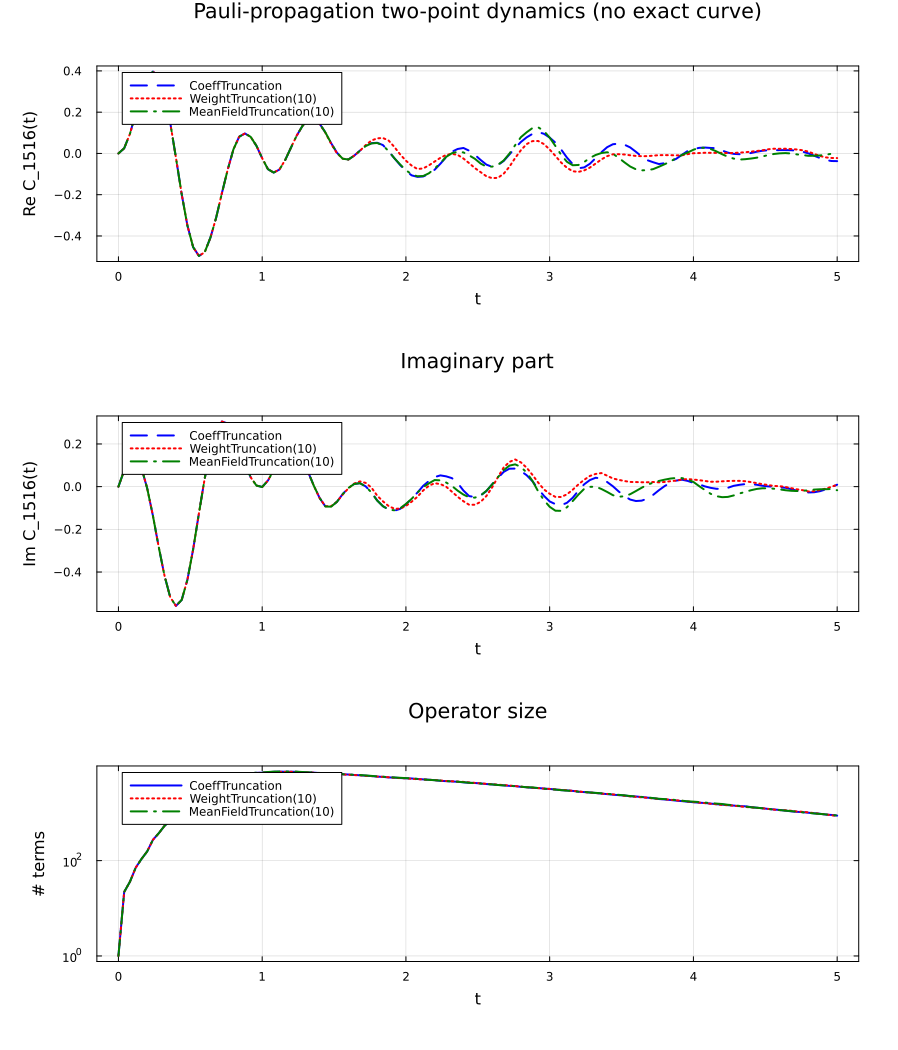

In [19]:
p_corr_re = plot(
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="Pauli-propagation two-point dynamics (no exact curve)",
    legend=:topleft, framestyle=:box, margin=5Plots.mm, dpi=100,
    size=(850, 450),
)
plot!(p_corr_re, times, real.(ev_coeff), label="CoeffTruncation", color=:blue, lw=2, ls=:dash)
plot!(p_corr_re, times, real.(ev_weight), label="WeightTruncation($(k_max_wt))", color=:red, lw=2, ls=:dot)
plot!(p_corr_re, times, real.(ev_mf), label="MeanFieldTruncation($(k_max))", color=:green, lw=2, ls=:dashdot)

p_corr_im = plot(
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="Imaginary part", legend=:topleft,
    framestyle=:box, margin=5Plots.mm, dpi=100,
    size=(850, 450),
)
plot!(p_corr_im, times, imag.(ev_coeff), label="CoeffTruncation", color=:blue, lw=2, ls=:dash)
plot!(p_corr_im, times, imag.(ev_weight), label="WeightTruncation($(k_max_wt))", color=:red, lw=2, ls=:dot)
plot!(p_corr_im, times, imag.(ev_mf), label="MeanFieldTruncation($(k_max))", color=:green, lw=2, ls=:dashdot)

p_terms = plot(
    times, nt_coeff,
    label="CoeffTruncation", color=:blue, lw=2,
    xlabel="t", ylabel="# terms", yscale=:log10,
    title="Operator size", legend=:topleft,
    framestyle=:box, margin=5Plots.mm, dpi=100,
    size=(850, 300),
)
plot!(p_terms, times, nt_weight, label="WeightTruncation($(k_max_wt))", color=:red, lw=2, ls=:dot)
plot!(p_terms, times, nt_mf, label="MeanFieldTruncation($(k_max))", color=:green, lw=2, ls=:dashdot)

plot(
    p_corr_re, p_corr_im, p_terms;
    layout=(3, 1), size=(900, 1050),
    framestyle=:box, margin=8Plots.mm, dpi=100,
)

## Weight Distribution Diagnostics

Use these panels to detect coefficient-mass blow-up or uncontrolled growth. Large growth in `sum |c|^2` usually means the propagated curve should not be trusted at late times.

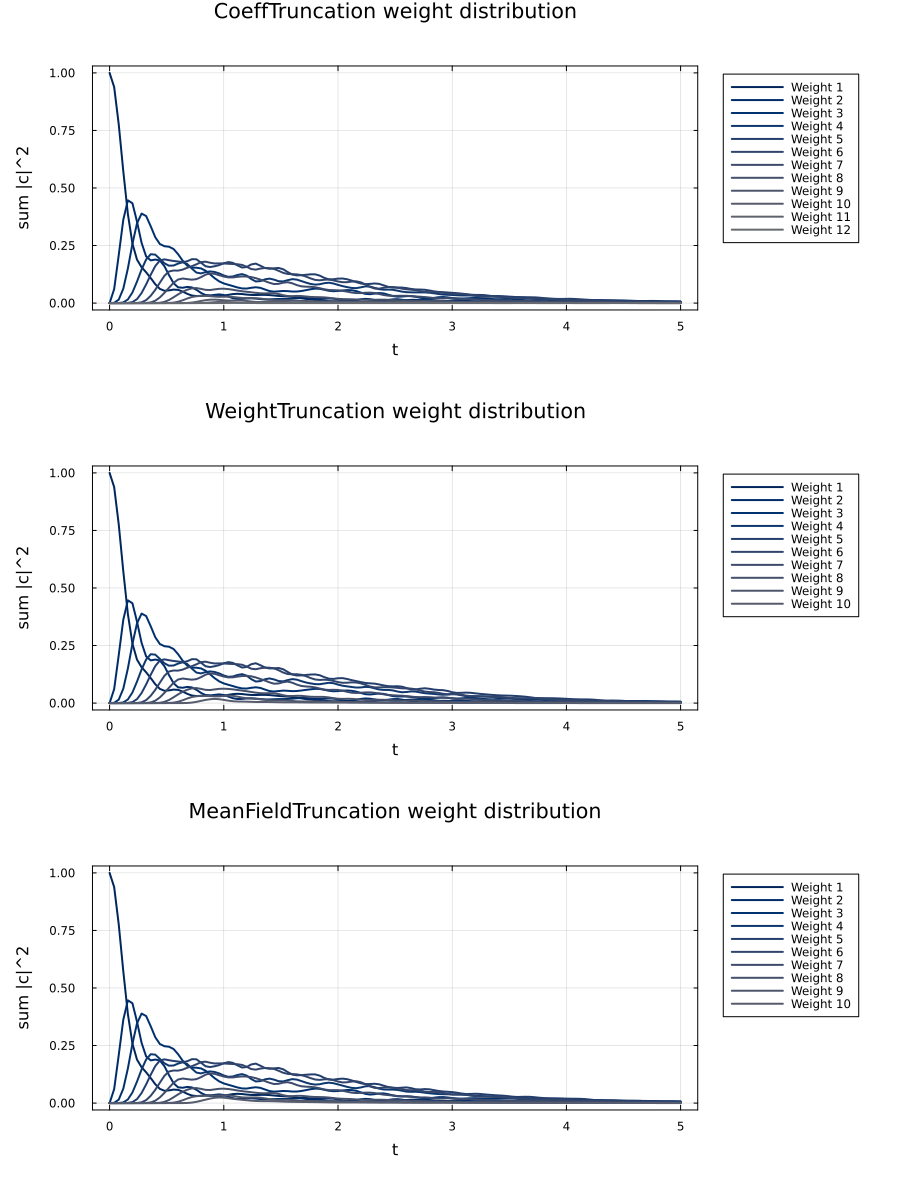

In [20]:
function plot_weight_distribution(times, W_mat, N; title="Weight distribution")
    p = plot(
        xlabel="t", ylabel="sum |c|^2", title=title,
        legend=:outertopright, framestyle=:box,
        margin=5Plots.mm, dpi=100, size=(850, 450),
    )
    colors = cgrad(:cividis, N + 1, categorical=true)
    for w in 0:N
        if maximum(W_mat[:, w + 1]) > 1e-12
            plot!(p, times, W_mat[:, w + 1], label="Weight $w", linewidth=2, color=colors[w + 1])
        end
    end
    return p
end

p_w_coeff = plot_weight_distribution(times, W_coeff, N; title="CoeffTruncation weight distribution")
p_w_weight = plot_weight_distribution(times, W_weight, N; title="WeightTruncation weight distribution")
p_w_mf = plot_weight_distribution(times, W_mf, N; title="MeanFieldTruncation weight distribution")

plot(
    p_w_coeff, p_w_weight, p_w_mf;
    layout=(3, 1), size=(900, 1200),
    framestyle=:box, margin=8Plots.mm, dpi=100,
)

## Optional Save

Uncomment this if you want to save the most recent plot from the notebook.

In [ ]:
# savefig("large_no_exact_correlator_dynamics.png")